In [24]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor

In [2]:
data_path = r"D:\Data Science and Machine Learning\ML and GenAI Projects\Car Price Prediction\data\sample_vehicle.csv"

### **STEP 1 - Load and Inspect Data**

In [3]:
df = pd.read_csv(data_path)
df.head()

,Unnamed: 0,id,url,region,region_url,price,year,manufacturer,model,condition,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,385568,7301987654,https://wichitafalls.craigslist.org/ctd/d/wich...,wichita falls,https://wichitafalls.craigslist.org,38590,2020.0,bmw,3 series 330i xdrive sedan,good,...,NaN,sedan,black,https://images.craigslist.org/00M0M_5PEtp5wnK6...,Carvana is the safer way to buy a car During t...,NaN,tx,33.890000,-98.510000,2021-04-05T07:52:45-0500
1,82318,7310604775,https://westslope.craigslist.org/ctd/d/grand-j...,western slope,https://westslope.craigslist.org,21995,2014.0,ram,2500 slt 4x4,NaN,...,NaN,pickup,white,https://images.craigslist.org/00n0n_5JgrqJrBq8...,2014 Ram 2500 SLT 4X4 TruckExterior Color: Br...,NaN,co,39.093933,-108.611602,2021-04-21T16:51:42-0600
2,44903,7310818650,https://palmsprings.craigslist.org/ctd/d/palm-...,palm springs,https://palmsprings.craigslist.org,0,2012.0,chevrolet,volt,NaN,...,NaN,hatchback,NaN,https://images.craigslist.org/00R0R_1oYg5bdxI7...,Coachella Valley Volkswagen STOCK #: T...,NaN,ca,33.755638,-116.286258,2021-04-22T07:30:41-0700
3,307507,7301875684,https://stillwater.craigslist.org/cto/d/stillw...,stillwater,https://stillwater.craigslist.org,9500,2011.0,kia,optima,good,...,full-size,sedan,black,https://images.craigslist.org/00C0C_5I8rZZ1DGC...,Only two total owners Only selling the car bec...,NaN,ok,36.104300,-97.060900,2021-04-04T19:41:11-0500
4,251229,7309995060,https://cnj.craigslist.org/ctd/d/farmingdale-2...,central NJ,https://cnj.craigslist.org,73495,2019.0,lincoln,navigator l,NaN,...,NaN,NaN,NaN,https://images.craigslist.org/00M0M_3XsPjkbjvG...,2019 Lincoln Navigator L CALL Automotive Avenu...,NaN,nj,40.204300,-74.177900,2021-04-20T15:53:11-0400


In [4]:
# Check null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 27 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    50000 non-null  int64  
 1   id            50000 non-null  int64  
 2   url           50000 non-null  object 
 3   region        50000 non-null  object 
 4   region_url    50000 non-null  object 
 5   price         50000 non-null  int64  
 6   year          49860 non-null  float64
 7   manufacturer  47872 non-null  object 
 8   model         49417 non-null  object 
 9   condition     29439 non-null  object 
 10  cylinders     28980 non-null  object 
 11  fuel          49621 non-null  object 
 12  odometer      49450 non-null  float64
 13  title_status  49009 non-null  object 
 14  transmission  49669 non-null  object 
 15  VIN           31158 non-null  object 
 16  drive         34690 non-null  object 
 17  size          13922 non-null  object 
 18  type          39078 non-nu

In [8]:
# df['size']

In [7]:
# Drop useless and high-missing columns
drop_cols = [
    'Unnamed: 0',
    'id',
    'url',
    'region_url',
    'VIN',
    'county',
    'image_url',
    'description',
    'size'
]

df = df.drop(columns=drop_cols)
df.shape

(50000, 18)

In [9]:
TARGET = "price"
X = df.drop(columns=[TARGET])
y = df[TARGET]

### **STEP 2: Train-Test split**

In [10]:
# Split first
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### **STEP 3: Exploratory Data Analysis**

In [19]:
TARGET = "price"
NUMERIC_COLS = X_train.select_dtypes(include=['int64', 'float64']).columns.to_list()
CATEGORICAL_COLS = X_train.select_dtypes(include=['object']).columns.to_list()

print(f"Numerical columns: {NUMERIC_COLS}\n")
print(f"Categorical columns: {CATEGORICAL_COLS}\n")

Numerical columns: ['year', 'odometer', 'lat', 'long']

Categorical columns: ['region', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel', 'title_status', 'transmission', 'drive', 'type', 'paint_color', 'state', 'posting_date']



In [ ]:
df = X_train.copy()

# y_train is separate from X_train, attach it for EDA convenience:
if TARGET not in df.columns:
    df[TARGET] = y_train.values

In [ ]:
## QUICK OVERVIEW

print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nMissing % per column:\n", (df.isna().mean() * 100).round(1).sort_values(ascending=False))
print("\nNumeric summary:\n", df[NUMERIC_COLS + [TARGET]].describe())
print("\nCategorical cardinality:\n", df[CATEGORICAL_COLS].nunique().sort_values(ascending=False))

Shape: (40000, 18)

Dtypes:
 region           object
year            float64
manufacturer     object
model            object
condition        object
cylinders        object
fuel             object
odometer        float64
title_status     object
transmission     object
drive            object
type             object
paint_color      object
state            object
lat             float64
long            float64
posting_date     object
price             int64
dtype: object

Missing % per column:
 cylinders       42.0
condition       41.2
drive           30.8
paint_color     30.7
type            21.7
manufacturer     4.3
title_status     2.0
long             1.6
lat              1.6
model            1.2
odometer         1.1
fuel             0.7
transmission     0.6
year             0.3
posting_date     0.0
region           0.0
state            0.0
price            0.0
dtype: float64

Numeric summary:
                year      odometer           lat          long         price
count  39885.

In [22]:
print("\nPrice before filtering — min/max/quantiles:")
print(df[TARGET].describe(percentiles=[.01, .05, .5, .95, .99]))


Price before filtering — min/max/quantiles:
count    4.000000e+04
mean     8.371649e+04
std      8.648415e+06
min      0.000000e+00
1%       0.000000e+00
5%       0.000000e+00
50%      1.395000e+04
95%      4.400425e+04
99%      6.749802e+04
max      1.410065e+09
Name: price, dtype: float64


Plot the distribution of price. Craigslist-style datasets almost always have garbage values like $0, $1, or $999999999, filter those out with a sanity range (e.g. keep $500–$150,000) before anything else, since these outliers will distort every later plot. Check skewness; price is usually right-skewed and may need a log transform for modeling.

In [ ]:
# Sanity filter for garbage listing prices — tune bounds to data
PRICE_MIN, PRICE_MAX = 500, 150_000
df_clean = df[(df[TARGET] >= PRICE_MIN) & (df[TARGET] <= PRICE_MAX)].copy()
print(f"\nDropped {len(df) - len(df_clean)} rows outside price range [{PRICE_MIN}, {PRICE_MAX}]")


Dropped 4000 rows outside price range [500, 150000]


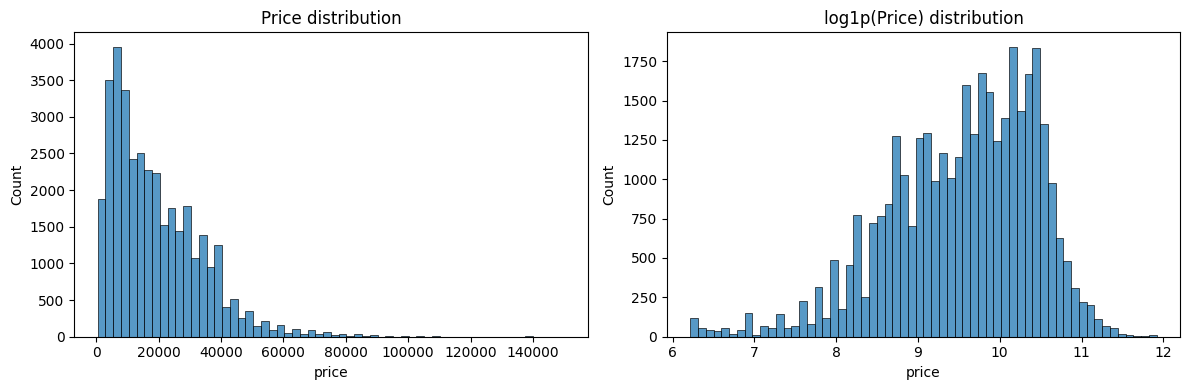


Skewness — raw: 1.47, log1p: -0.72


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df_clean[TARGET], bins=60, ax=axes[0])
axes[0].set_title("Price distribution")
sns.histplot(np.log1p(df_clean[TARGET]), bins=60, ax=axes[1])
axes[1].set_title("log1p(Price) distribution")
plt.tight_layout()
plt.show()
print(f"\nSkewness — raw: {df_clean[TARGET].skew():.2f}, log1p: {np.log1p(df_clean[TARGET]).skew():.2f}")

Recompute null percentages on the train set after your drops. For condition, cylinders, drive, type, paint_color, look at whether missingness correlates with price (e.g. do listings missing 'condition' tend to be cheaper or from certain manufacturers?), this tells you whether to impute with a real value or an explicit 'unknown' category.

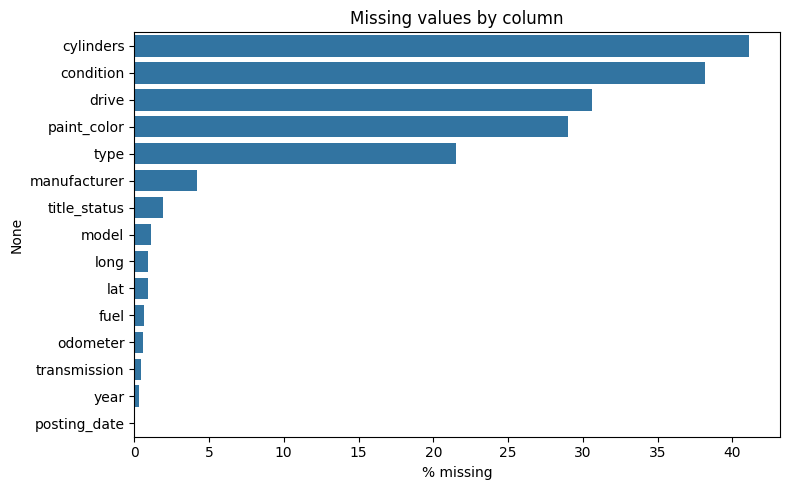

In [26]:
## Missing Patterns

missing_pct = df_clean.isna().mean().sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]
 
plt.figure(figsize=(8, 5))
sns.barplot(x=missing_pct.values * 100, y=missing_pct.index)
plt.xlabel("% missing")
plt.title("Missing values by column")
plt.tight_layout()
plt.show()

In [27]:
# Does missingness in a column correlate with price? Example for 'condition'
for col in ["condition", "cylinders", "drive", "type", "paint_color"]:
    if col in df_clean.columns:
        tmp = df_clean.copy()
        tmp[f"{col}_missing"] = tmp[col].isna()
        print(f"\nMean price by {col} missing flag:")
        print(tmp.groupby(f"{col}_missing")[TARGET].mean())


Mean price by condition missing flag:
condition_missing
False    18359.753426
True     20734.430401
Name: price, dtype: float64

Mean price by cylinders missing flag:
cylinders_missing
False    18073.036516
True     20974.751891
Name: price, dtype: float64

Mean price by drive missing flag:
drive_missing
False    19528.598671
True     18671.524505
Name: price, dtype: float64

Mean price by type missing flag:
type_missing
False    20218.966452
True     15789.040945
Name: price, dtype: float64

Mean price by paint_color missing flag:
paint_color_missing
False    19860.402473
True     17813.294889
Name: price, dtype: float64


Histogram/boxplot for year and odometer. Look for impossible values (year > current year, year < 1900, odometer = 0 or in the millions) — these are almost certainly data entry errors, not real outliers, and should usually be dropped or capped rather than transformed.

In [ ]:
## Univariate - Numeric features

for col in NUMERIC_COLS:
    if col in df_clean.columns:
        print(f"\n{col} summary:")
        print(df_clean[col].describe(percentiles=[.01, .05, .5, .95, .99]))


year summary:
count    35887.000000
mean      2010.992671
std          9.502457
min       1900.000000
1%        1967.000000
5%        1998.000000
50%       2013.000000
95%       2020.000000
99%       2020.000000
max       2022.000000
Name: year, dtype: float64

odometer summary:
count    3.578400e+04
mean     9.689381e+04
std      1.584295e+05
min      0.000000e+00
1%       2.183000e+01
5%       7.209000e+03
50%      8.742200e+04
95%      2.046324e+05
99%      2.750000e+05
max      1.000000e+07
Name: odometer, dtype: float64

lat summary:
count    35662.000000
mean        38.504282
std          5.865959
min        -81.838232
1%          25.946257
5%          28.136040
50%         39.198076
95%         47.044390
99%         48.756909
max         82.390818
Name: lat, dtype: float64

long summary:
count    35662.000000
mean       -94.418488
std         18.143387
min       -159.590001
1%        -149.867270
5%        -122.450520
50%        -88.051628
95%        -72.938438
99%        -71.09

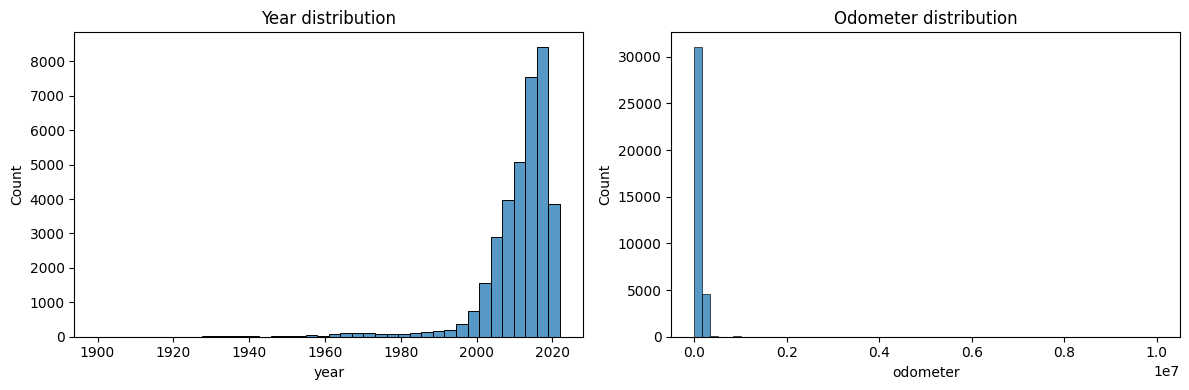

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df_clean["year"].dropna(), bins=40, ax=axes[0])
axes[0].set_title("Year distribution")
sns.histplot(df_clean["odometer"].dropna(), bins=60, ax=axes[1])
axes[1].set_title("Odometer distribution")
plt.tight_layout()
plt.show()

In [30]:
# Sanity checks for impossible values
current_year = pd.Timestamp.now().year
bad_year = df_clean[(df_clean["year"] > current_year) | (df_clean["year"] < 1900)]
bad_odo = df_clean[(df_clean["odometer"] <= 0) | (df_clean["odometer"] > 500_000)]
print(f"\nRows with impossible year: {len(bad_year)}")
print(f"Rows with impossible odometer: {len(bad_odo)}")


Rows with impossible year: 0
Rows with impossible odometer: 207


For manufacturer, model, fuel, transmission, drive, type, title_status, paint_color, state: check cardinality (unique value counts) and frequency distribution. model will have very high cardinality — decide now whether to bucket rare categories into 'other' before encoding.

In [35]:
## Univariate - Categorical features
for col in CATEGORICAL_COLS:
    if col in df_clean.columns:
        n_unique = df_clean[col].nunique()
        print(f"\n{col}: {n_unique} unique values")
        print(df_clean[col].value_counts(normalize=True).head(10))


region: 402 unique values
region
columbus                 0.008917
jacksonville             0.008472
grand rapids             0.007972
boston                   0.007889
sarasota-bradenton       0.007861
phoenix                  0.007833
denver                   0.007806
ft myers / SW florida    0.007694
tampa bay area           0.007528
south florida            0.007528
Name: proportion, dtype: float64

manufacturer: 42 unique values
manufacturer
ford         0.173302
chevrolet    0.130853
toyota       0.084462
honda        0.052770
nissan       0.046537
jeep         0.045580
ram          0.043985
gmc          0.040013
bmw          0.036562
dodge        0.032474
Name: proportion, dtype: float64

model: 7666 unique values
model
f-150             0.018879
silverado 1500    0.012529
1500              0.009748
camry             0.007641
civic             0.006883
2500              0.006799
accord            0.006714
silverado         0.006574
altima            0.006546
escape            0

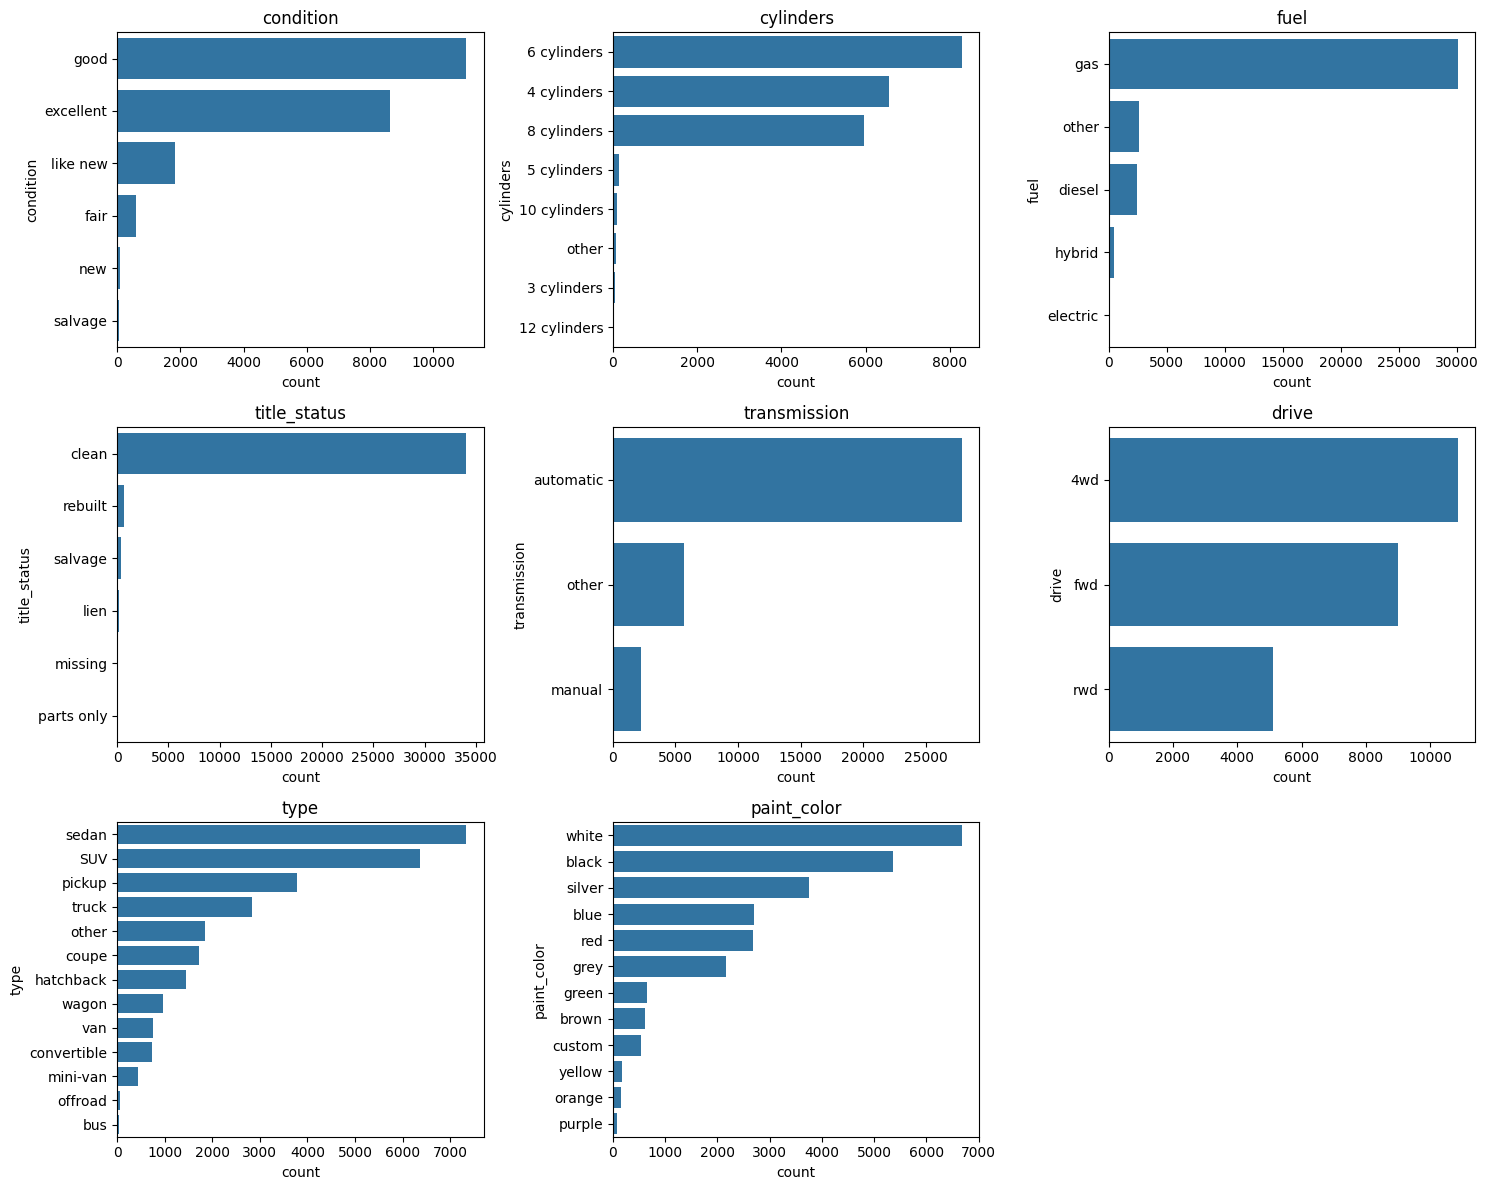

In [36]:
# Bar plots for lower-cardinality categoricals only
low_card_cols = [c for c in CATEGORICAL_COLS if c in df_clean.columns and df_clean[c].nunique() <= 20]
n = len(low_card_cols)
fig, axes = plt.subplots((n + 2) // 3, 3, figsize=(15, 4 * ((n + 2) // 3)))
axes = axes.flatten()
for i, col in enumerate(low_card_cols):
    order = df_clean[col].value_counts().index
    sns.countplot(y=df_clean[col], order=order, ax=axes[i])
    axes[i].set_title(col)
for j in range(i + 1, len(axes)):
    axes[j].axis("off")
plt.tight_layout()
plt.show()

Scatter plots of price vs year and price vs odometer (expect negative correlation with odometer, positive with year). These relationships are usually non-linear, which hints that tree-based models or engineered features (e.g. car age = current_year - year) will help.

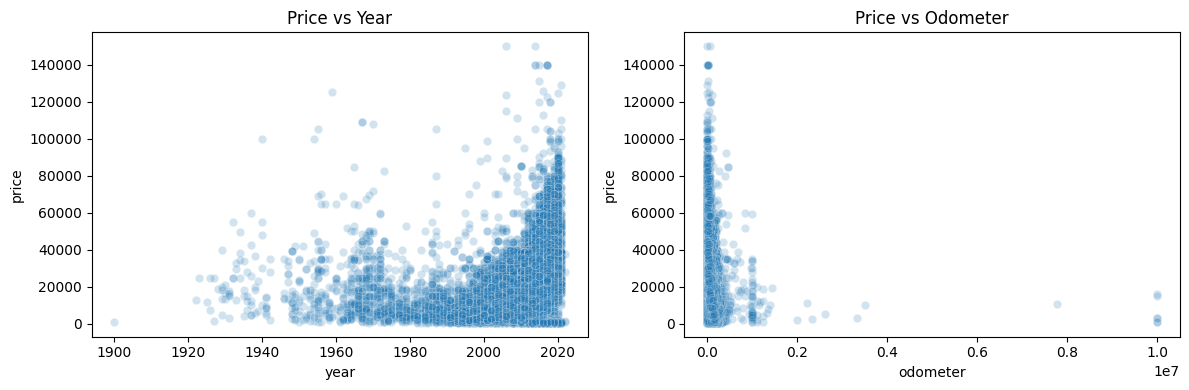

In [37]:
## BIVARIATE — NUMERIC FEATURES vs PRICE

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.scatterplot(data=df_clean, x="year", y=TARGET, alpha=0.2, ax=axes[0])
axes[0].set_title("Price vs Year")
sns.scatterplot(data=df_clean, x="odometer", y=TARGET, alpha=0.2, ax=axes[1])
axes[1].set_title("Price vs Odometer")
plt.tight_layout()
plt.show()

In [38]:
#  Engineered feature: car age often correlates more cleanly than raw year

df_clean["car_age"] = current_year - df_clean["year"]
print("\nCorrelation of car_age with price:", df_clean["car_age"].corr(df_clean[TARGET]))
print("Correlation of odometer with price:", df_clean["odometer"].corr(df_clean[TARGET]))


Correlation of car_age with price: -0.35560291726867965
Correlation of odometer with price: -0.22417778099284458


Boxplots of price grouped by manufacturer, type, fuel, transmission, title_status, condition. This shows which categories actually move the price and flags any category with very few listings (unreliable price estimates, candidate for grouping into 'other').

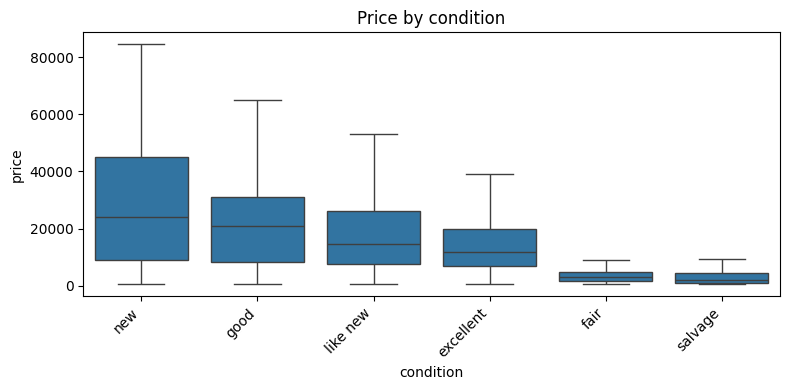

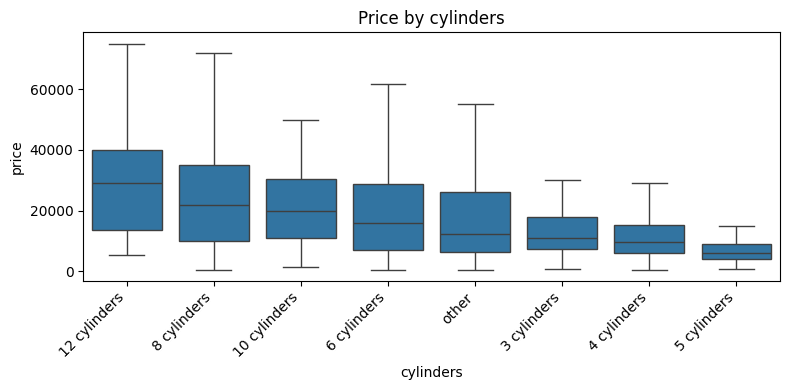

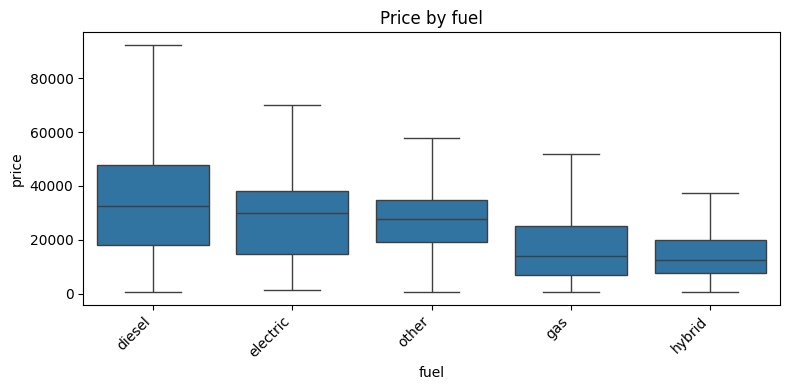

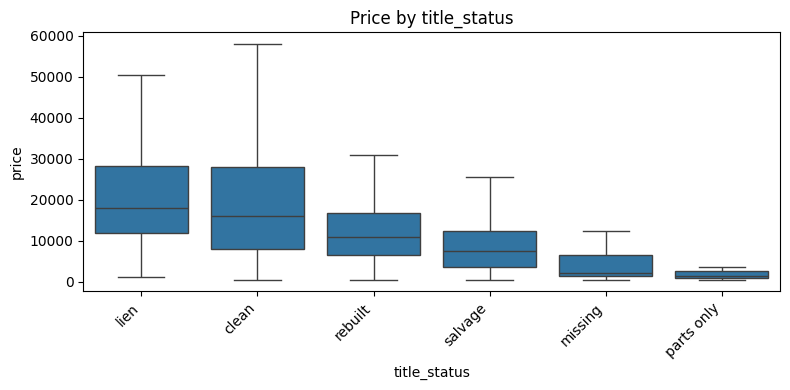

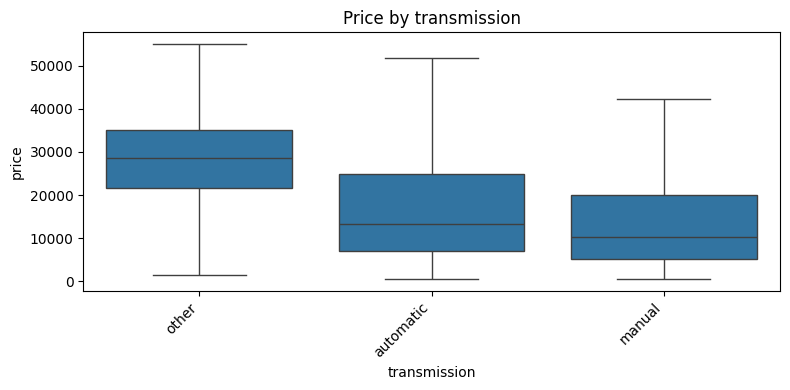

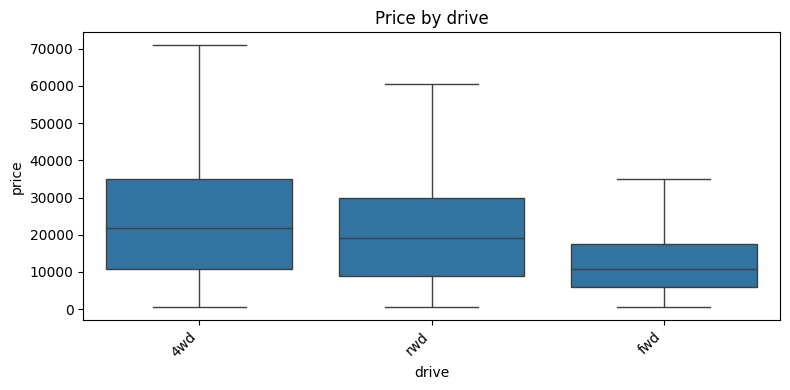

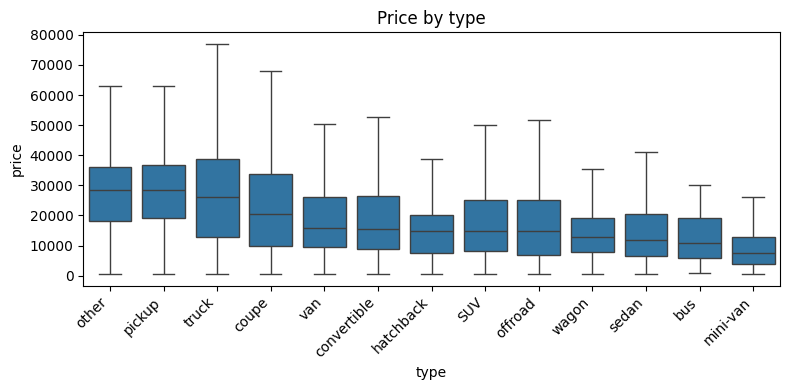

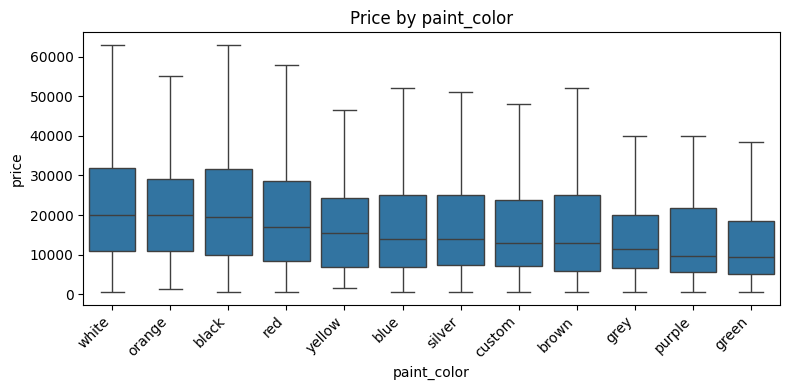

In [ ]:
# BIVARIATE — CATEGORICAL FEATURES vs PRICE

for col in low_card_cols:
    plt.figure(figsize=(8, 4))
    order = df_clean.groupby(col)[TARGET].median().sort_bvalues(ascending=False).index
    sns.boxplot(data=df_clean, x=col, y=TARGET, order=order, showfliers=False)
    plt.xticks(rotation=45, ha="right")
    plt.title(f"Price by {col}")
    plt.tight_layout()
    plt.show()

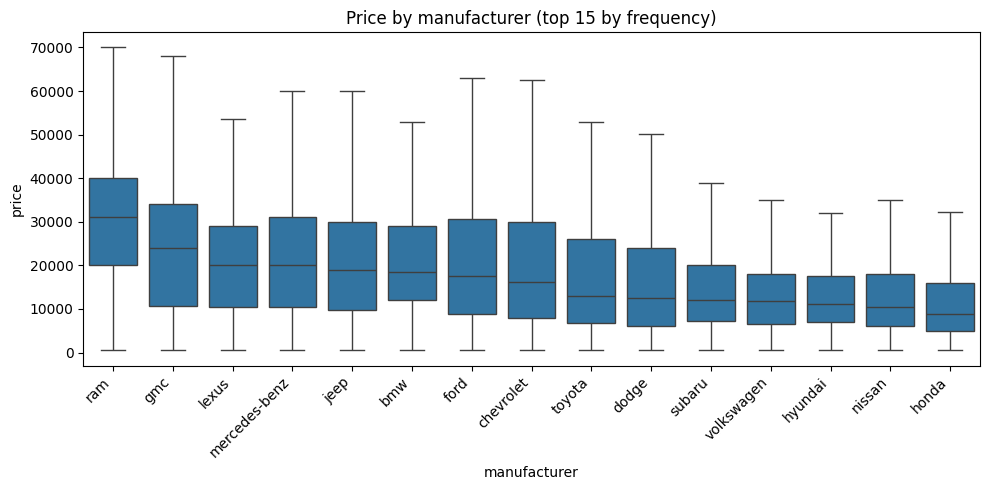

In [40]:
# For high-cardinality 'manufacturer' / 'model', look at top-N by frequency only

if "manufacturer" in df_clean.columns:
    top_manufacturers = df_clean["manufacturer"].value_counts().head(15).index
    plt.figure(figsize=(10, 5))
    order = (df_clean[df_clean["manufacturer"].isin(top_manufacturers)]
             .groupby("manufacturer")[TARGET].median().sort_values(ascending=False).index)
    sns.boxplot(data=df_clean[df_clean["manufacturer"].isin(top_manufacturers)],
                x="manufacturer", y=TARGET, order=order, showfliers=False)
    plt.xticks(rotation=45, ha="right")
    plt.title("Price by manufacturer (top 15 by frequency)")
    plt.tight_layout()
    plt.show()

Correlation matrix/heatmap for numeric features (year, odometer, lat, long, price). Watch for redundant signal — e.g. if you kept both lat/long and state/region, check how much overlap they share before deciding which location representation to keep.

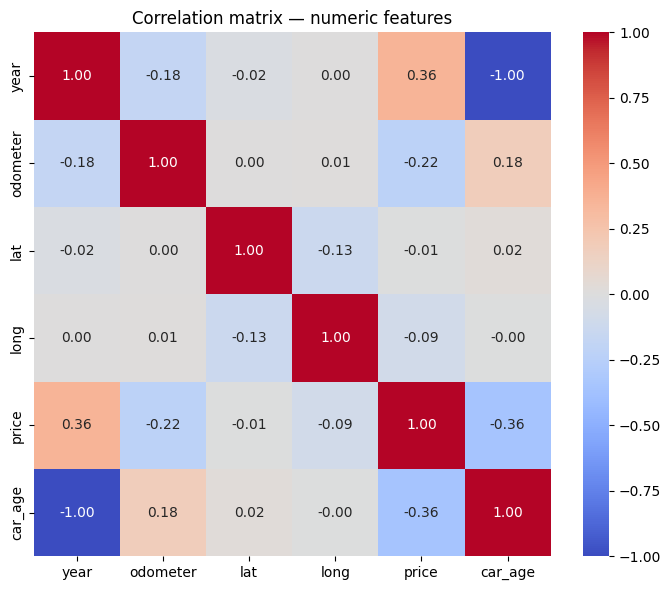

In [41]:
# CORRELATION / MULTICOLLINEARITY (numeric features only)

num_for_corr = [c for c in NUMERIC_COLS + [TARGET, "car_age"] if c in df_clean.columns]
corr = df_clean[num_for_corr].corr()
 
plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix — numeric features")
plt.tight_layout()
plt.show()

If keeping state/region or lat/long, check whether price varies meaningfully by location (regional demand/cost-of-living effects are real for car prices). If you extracted date features from posting_date, check for seasonal trends in price or listing volume.

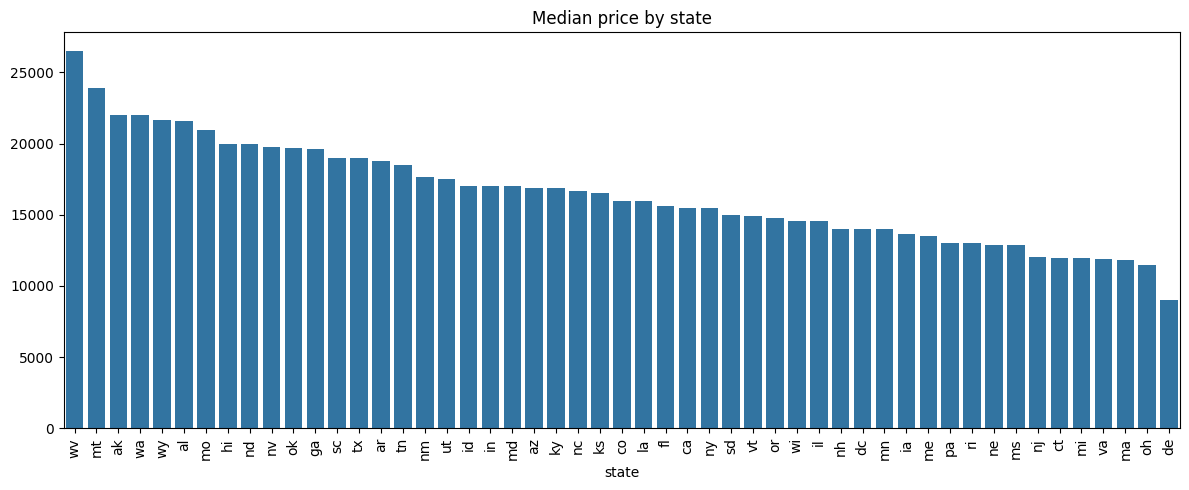

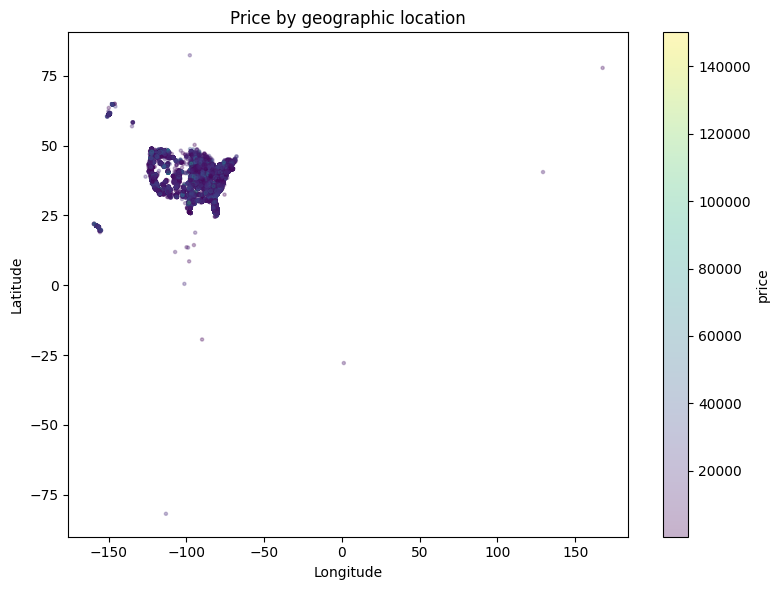

In [42]:
# GEOGRAPHIC / TEMPORAL PATTERNS

if "state" in df_clean.columns:
    state_price = df_clean.groupby("state")[TARGET].median().sort_values(ascending=False)
    plt.figure(figsize=(12, 5))
    sns.barplot(x=state_price.index, y=state_price.values)
    plt.xticks(rotation=90)
    plt.title("Median price by state")
    plt.tight_layout()
    plt.show()
 
if "lat" in df_clean.columns and "long" in df_clean.columns:
    plt.figure(figsize=(8, 6))
    sc = plt.scatter(df_clean["long"], df_clean["lat"], c=df_clean[TARGET],
                      cmap="viridis", alpha=0.3, s=5)
    plt.colorbar(sc, label="price")
    plt.title("Price by geographic location")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.tight_layout()
    plt.show()